In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from astropy.io import fits
import os
import glob
from tqdm import tqdm
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import LogNorm
from scipy.integrate import cumulative_trapezoid
from scipy.special import jv
from scipy.interpolate import RegularGridInterpolator, interp1d
from astropy.cosmology import Planck18 as cosmo
from astropy import constants as con
from astropy import units as u
from scipy.integrate import trapezoid
from scipy.stats import gaussian_kde
from scipy.ndimage import gaussian_filter
from joblib import Parallel, delayed

import BaryonForge as bfg
import pyccl as ccl

import warnings
warnings.filterwarnings("ignore")

%matplotlib inline
%config InlineBackend.figure_format = 'retina'
plt.rcParams.update(
    {
        'text.usetex': False,
        'font.family': 'stixgeneral',
        'mathtext.fontset': 'stix',
    }
)
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['image.origin'] = 'lower'
sns.set_context('talk') 
sns.set(font_scale=1.5)
sns.set_palette('colorblind')
sns.set_style('ticks')
plt.rcParams['font.family'] = 'Times New Roman'

cmap = plt.get_cmap("rainbow_r"); colors = [cmap(i) for i in np.linspace(0, 1, 5)]

mpl.rcParams['axes.linewidth'] = 2   # thickness of the plot box
mpl.rcParams['xtick.major.width'] = 2
mpl.rcParams['ytick.major.width'] = 2
mpl.rcParams['xtick.minor.width'] = 1
mpl.rcParams['ytick.minor.width'] = 1

mpl.rcParams['xtick.major.size'] = 10
mpl.rcParams['ytick.major.size'] = 10
mpl.rcParams['xtick.minor.size'] = 5
mpl.rcParams['ytick.minor.size'] = 5

from sensitivity_funcs import *


In [2]:
default_dict = {
    'log_Mc': 13, 
    'Om0': cosmo.Om0, 
    'Ob0': cosmo.Ob0, 
    'h': cosmo.H0.value/100, 
    'sigma8': 0.8111, 
    'm_nu': 0.06, 
    'w0': -1, 
    'wa': 0
}
param_names = np.array(list(default_dict.keys()))
default_values = np.array(list(default_dict.values()))

param_ranges = {
    'log_Mc': [12.5, 13.5],
    'Om0': [0.25, 0.35],
    'Ob0': [0.04, 0.06],
    'h': [0.65, 0.7],
    'sigma8': [0.7, 0.9],
    'm_nu': [0.1, 0.2],
    'w0': [-1.5, -0.5], 
    'wa': [-0.5, 0.5],
}

# all_rows = [default_values.copy()]
# for i, param in enumerate(param_names):
#     for val in param_ranges[param]:
#         row = default_values.copy()
#         row[i] = val
#         all_rows.append(row)
# df = pd.DataFrame(all_rows, columns=param_names)
# df.to_csv('forecasts/params.csv')
df = pd.read_csv('data/forecasts/precomputed_power_spectra/params.csv')
df.head()


,Unnamed: 0,log_Mc,Om0,Ob0,h,sigma8,m_nu,w0,wa
0,0,13.0,0.30966,0.04897,0.6766,0.8111,0.0,-1.0,0.0
1,1,12.5,0.30966,0.04897,0.6766,0.8111,0.0,-1.0,0.0
2,2,13.5,0.30966,0.04897,0.6766,0.8111,0.0,-1.0,0.0
3,3,13.0,0.25000,0.04897,0.6766,0.8111,0.0,-1.0,0.0
4,4,13.0,0.35000,0.04897,0.6766,0.8111,0.0,-1.0,0.0


In [3]:
k_fields = np.geomspace(1e-4, 1e6, 1000)
# mass_def=ccl.halos.massdef.MassDef200c
# c_M_relation = ccl.halos.concentration.ConcentrationDiemer15
# fft_precision = dict(padding_lo_fftlog = 1e-8, padding_hi_fftlog = 1e8, n_per_decade = 100)

# pre-computed power spectra
# for i in tqdm(range(len(df))):
#     os.mkdir('data/forecasts/precomputed_power_spectra/params_{}'.format(i))
#     for j in range(len(redshifts)):
#         from astropy.cosmology import Planck18 as cosmo
#         cosmo = ccl.Cosmology(Omega_c = df.Om0[i]-df.Ob0[i], 
#                               Omega_b = df.Ob0[i], 
#                               h = df.h[i], 
#                               sigma8 = df.sigma8[i], 
#                               m_nu = df.m_nu[i],
#                               w0 = df.w0[i],
#                               wa = df.wa[i],
#                               n_s = 0.9665, 
#                               matter_power_spectrum='linear', 
# #                               extra_parameters={"camb": {"dark_energy_model": 'ppf'}}
#                              )
#         rho  = ccl.rho_x(cosmo, 1/(1+redshifts[j]), 'matter', is_comoving = True)*cosmo.cosmo.params.Omega_b/(cosmo.cosmo.params.Omega_b+cosmo.cosmo.params.Omega_c)
        
#         par = dict(theta_ej=3.5, theta_co=0.1, M_c=(10**df.log_Mc[i])/df.h[i], mu_beta=1, 
#                    eta=0.2, eta_delta=0.2, tau=-1.5, tau_delta=0, A=0.055/2, 
#                    M1=2.5e11/df.h[i], epsilon_h=0.015, a=0.3, n=2, epsilon=4, p=0.3, 
#                    q=0.707, gamma=2.5, delta=7)
        
#         DMO = bfg.Profiles.Schneider19.DarkMatter(**par, r_min_int=1e-3, r_max_int=1e2, r_steps=500, mass_def=mass_def, c_M_relation=c_M_relation)
#         GAS = bfg.Profiles.Schneider19.Gas(**par, r_min_int=1e-3, r_max_int=1e2, r_steps=500, mass_def=mass_def, c_M_relation=c_M_relation)
#         STR = bfg.Profiles.Schneider19.Stars(**par, r_min_int=1e-6, r_max_int=5, r_steps=500, mass_def=mass_def, c_M_relation=c_M_relation)
#         CLM = bfg.Profiles.Schneider19.CollisionlessMatter(**par, max_iter=2, reltol=5e-2, r_steps=500, mass_def=mass_def, c_M_relation=c_M_relation)
#         DMB = bfg.Profiles.Schneider19.DarkMatterBaryon(**par,
#                                                         gas=GAS, stars=STR, collisionlessmatter=CLM, darkmatter=DMO,
#                                                         twohalo=bfg.Profiles.misc.Zeros(), 
#                                                         r_steps=500, mass_def=mass_def, c_M_relation=c_M_relation)    
#         DMB = DMB / rho
#         GAS = GAS / (rho*df.Ob0[i]/df.Om0[i])
#         for p in [DMB, GAS]:
#             p.update_precision_fftlog(**fft_precision)

#         HMC  = HMCalculator_NoCorrection(mass_function = 'Tinker08', halo_bias = 'Tinker10', 
#                                          mass_def = ccl.halos.massdef.MassDef200c, 
#                                          log10M_min = 6, log10M_max = 15, nM = 100)
        
#         P_gm = ccl.halos.pk_2pt.halomod_power_spectrum(cosmo, HMC, k_fields, 1/(1+redshifts[j]), GAS, prof2=DMB)
#         np.save('forecasts/params_{}/P_gm_z={}.npy'.format(i, round(redshifts[j], 2)), P_gm)
        
#         P_gg = ccl.halos.pk_2pt.halomod_power_spectrum(cosmo, HMC, k_fields, 1/(1+redshifts[j]), GAS)
#         np.save('forecasts/params_{}/P_gg_z={}.npy'.format(i, round(redshifts[j], 2)), P_gg)

#         P_mm = ccl.halos.pk_2pt.halomod_power_spectrum(cosmo, HMC, k_fields, 1/(1+redshifts[j]), DMB)
#         np.save('forecasts/params_{}/P_mm_z={}.npy'.format(i, round(redshifts[j], 2)), P_mm)
        


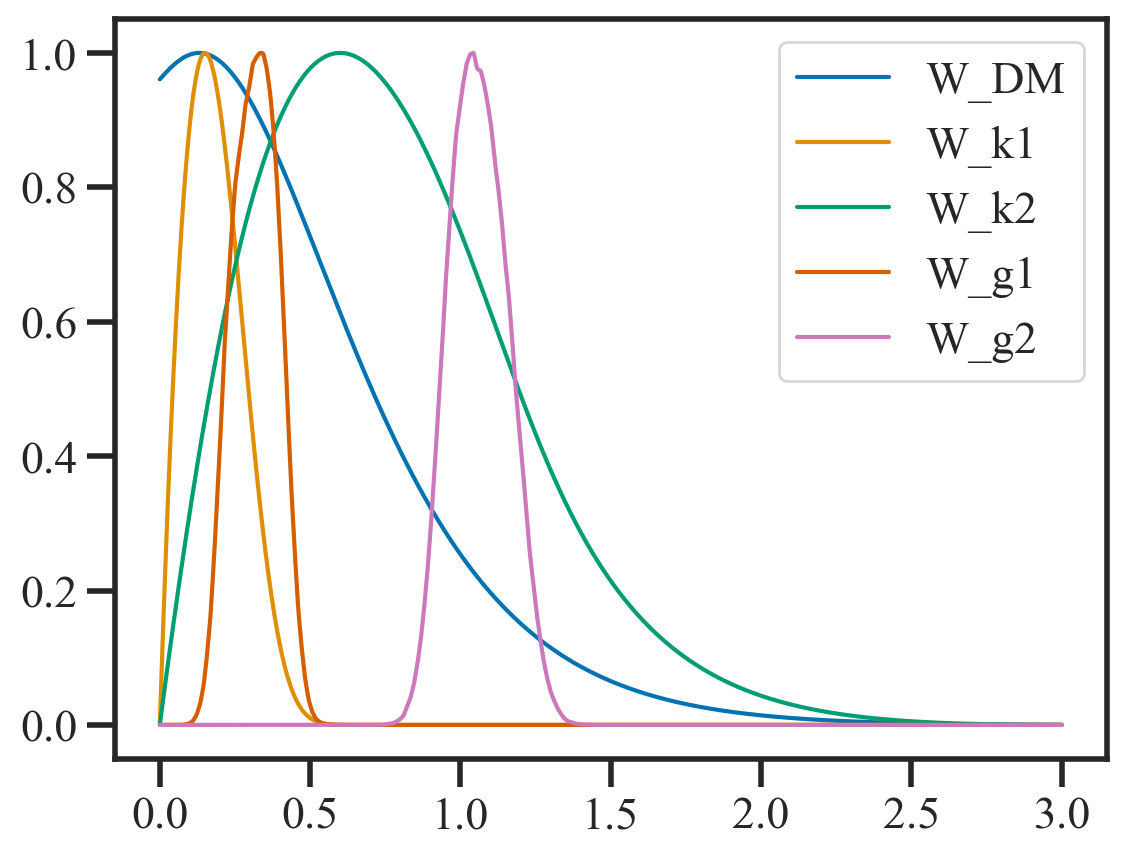

In [4]:
nz_file_k = 'data/forecasts/source_LSSTY1.nz'
nz_file_g = 'data/forecasts/lens_LSSTY1.nz'
zbin_k_idx1, zbin_k_idx2 = 1, 5
zbin_g_idx1, zbin_g_idx2 = 1, 5
lmin, lmax = 1, 10000
omega_sky = 4*np.pi*0.4
Nfrb = 1e4
Ngal1=3.592707*12300*3600; Ngal2=2.252406*12300*3600
zmin, zmax = 0.0001, 3

cosmo_calc = CosmologyCalculator(H0_kms_per_Mpc=default_dict["h"]*100, 
                                 Ob0=default_dict["Ob0"], 
                                 Om0=default_dict["Om0"], 
                                 sigma8=default_dict["sigma8"], 
                                 m_nu=default_dict["m_nu"], 
                                 w0=default_dict["w0"], 
                                 wa=default_dict["wa"])

src_dist = SourceDistribution(cosmo_calc, nz_file_k=nz_file_k, nz_file_g=nz_file_g,
                              zmin=zmin, zmax=zmax, zbin_k_idx1=zbin_k_idx1, zbin_k_idx2=zbin_k_idx2, 
                              zbin_g_idx1=zbin_g_idx1, zbin_g_idx2=zbin_g_idx2, 
                              Nfrb=Nfrb, Ngal1=Ngal1, Ngal2=Ngal2)

plt.plot(src_dist.z_grid, (src_dist.W_DM_wt*c/src_dist.Hz)/np.max(src_dist.W_DM_wt*c/src_dist.Hz), label="W_DM")

plt.plot(src_dist.z_grid, (src_dist.W_k_wt1*c/src_dist.Hz)/np.max(src_dist.W_k_wt1*c/src_dist.Hz), label="W_k1")
plt.plot(src_dist.z_grid, (src_dist.W_k_wt2*c/src_dist.Hz)/np.max(src_dist.W_k_wt2*c/src_dist.Hz), label="W_k2")

plt.plot(src_dist.z_grid, (src_dist.W_g_wt1*c/src_dist.Hz)/np.max(src_dist.W_g_wt1*c/src_dist.Hz), label="W_g1")
plt.plot(src_dist.z_grid, (src_dist.W_g_wt2*c/src_dist.Hz)/np.max(src_dist.W_g_wt2*c/src_dist.Hz), label="W_g2")

plt.legend()


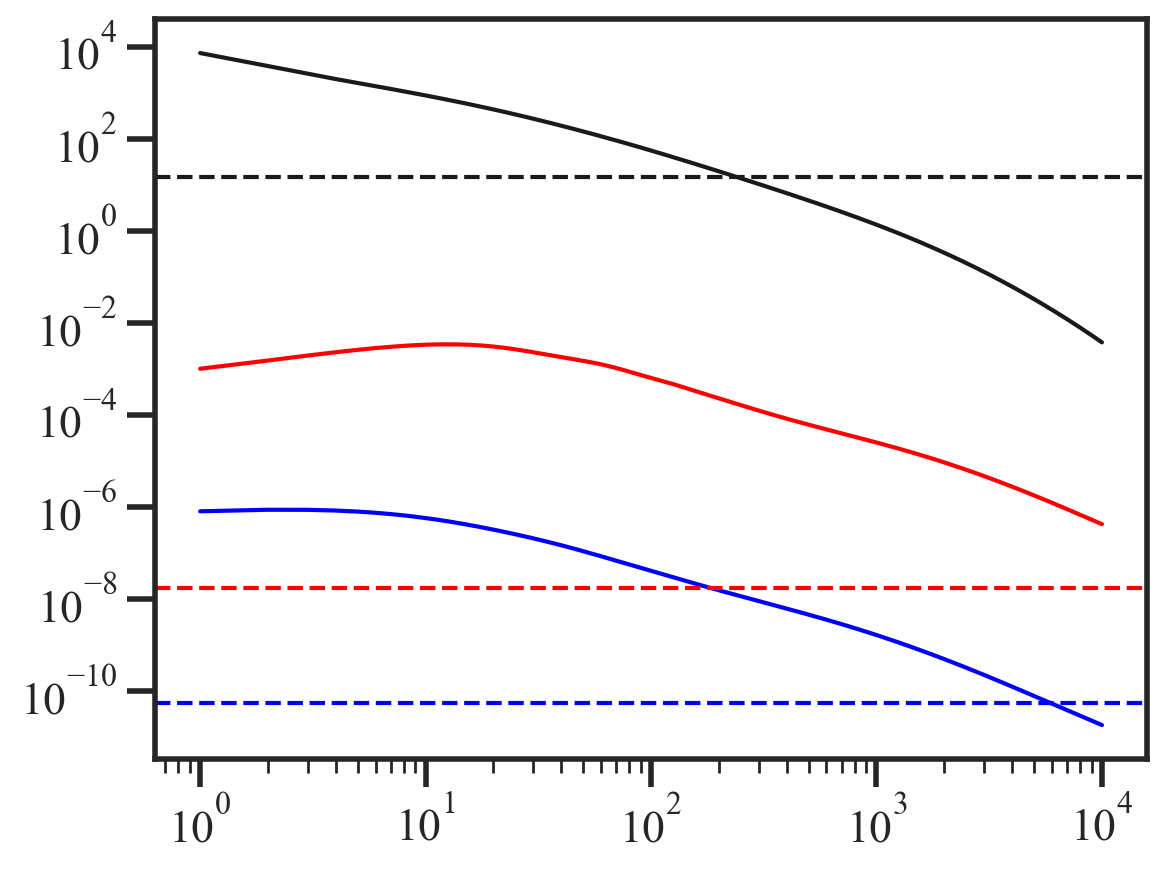

In [5]:
z_grid = src_dist.z_grid
chi_grid = src_dist.chi
Hz_grid = src_dist.Hz
logk_grid = np.log10(k_fields)
ells = np.arange(lmin, lmax + 1)


def Cell(W1, W2, z_P, P, b1=1, b2=1, z_grid=z_grid, chi_grid=chi_grid, Hz_grid=Hz_grid, logk_grid=logk_grid, ells=ells):
    """Compute angular power spectrum C_ell via Limber approximation."""
    pts_z = np.repeat(z_grid[None, :], len(ells), axis=0)
    k_grid = ((ells[:, None]+0.5) / chi_grid[None, :])
    pts_logk = np.log10(k_grid)
    
    pts_z = np.stack([pts_z.ravel(), pts_logk.ravel()], axis=-1)
    
    logP_interpolator = RegularGridInterpolator((z_P, np.log10(k_fields)), np.log10(P), bounds_error=False, fill_value=None)
    logP_vals = logP_interpolator(pts_z).reshape(len(ells), len(z_grid))
    
    Pk_values_Mpc3 = (10.0**logP_vals)*b1*b2
    integrand_z = (W1[None, :] * W2[None, :] / chi_grid[None, :]**2) * Pk_values_Mpc3 * (c / Hz_grid[None, :])
    return trapezoid(integrand_z, z_grid, axis=1)


z_P, P = precomputed_power_spectra("params_0", "gg")
C_ell_DD = Cell(src_dist.W_DM_wt, src_dist.W_DM_wt, z_P, P)

z_P, P = precomputed_power_spectra("params_0", "mm")
C_ell_kk = Cell(src_dist.W_k_wt1, src_dist.W_k_wt1, z_P, P)

z_P, P = precomputed_power_spectra("params_0", "mm")
C_ell_gg = Cell(src_dist.W_g_wt1, src_dist.W_g_wt1, z_P, P, b1=1.24, b2=1.24)

zmean_f = np.mean(np.random.choice(src_dist.z_grid, 10000, p=src_dist.dn2d_dz_frb/np.sum(src_dist.dn2d_dz_frb)))
DMhost_var = 100**2
sigma_e = 0.36769552621
    
var_DMfield = np.trapz(ells*C_ell_DD, ells)/(2*np.pi)
var_GALfield = np.trapz(ells*C_ell_gg, ells)/(2*np.pi)
var_KAPPAfield = np.trapz(ells*C_ell_kk, ells)/(2*np.pi)

N_DM = ((DMhost_var/((1+zmean_f)**2)) + (var_DMfield))/(src_dist.n2d_mean_frb)
N_g1 = (1+var_GALfield)/src_dist.n2d_mean_g1
N_k1 = ((sigma_e**2)/src_dist.n2d_mean_g1)/2

plt.loglog(ells, C_ell_kk, color="blue")
plt.axhline(N_k1, color="blue", ls="--")

plt.loglog(ells, C_ell_DD, color="k")
plt.axhline(N_DM, color="k", ls="--")

plt.loglog(ells, C_ell_gg, color="red")
plt.axhline(N_g1, color="red", ls="--")



In [6]:
def return_data_vectors(dir_idx):
    cosmo_calc = CosmologyCalculator(H0_kms_per_Mpc=100*df["h"][dir_idx], Ob0=df["Ob0"][dir_idx], 
                                     Om0=df["Om0"][dir_idx], sigma8=df["sigma8"][dir_idx], 
                                     m_nu=df["m_nu"][dir_idx], w0=df["w0"][dir_idx], wa=df["wa"][dir_idx])
    z_P, P_mm = precomputed_power_spectra("params_{}".format(dir_idx), "mm")
    z_P, P_gm = precomputed_power_spectra("params_{}".format(dir_idx), "gm"); P_gm[P_gm<0] = 1e-100
    z_P, P_gg = precomputed_power_spectra("params_{}".format(dir_idx), "gg")
    galaxy_bias = {1: 1.24, 2: 1.36, 3: 1.47, 4: 1.60, 5: 1.76}

    order = [11,21,31,41,51,22,32,42,52,33,43,53,44,54,55]

    shear_shear = {}
    for ij in order:
        zbin_idx1 = int((ij%100 - ij%10)/10)
        zbin_idx2 = ij%10
        src_dist = SourceDistribution(cosmo_calc, nz_file_k=nz_file_k, nz_file_g=nz_file_g,
                                      zmin=zmin, zmax=zmax, zbin_k_idx1=zbin_idx1, zbin_k_idx2=zbin_idx2, 
                                      zbin_g_idx1=zbin_g_idx1, zbin_g_idx2=zbin_g_idx2, 
                                      Nfrb=Nfrb, Ngal1=Ngal1, Ngal2=Ngal2)
        shear_shear[ij] = Cell(src_dist.W_k_wt1, src_dist.W_k_wt1, z_P, P_mm, chi_grid=src_dist.chi, Hz_grid=src_dist.Hz)
        
    galaxy_galaxy = {}
    for ij in order:
        zbin_idx1 = int((ij%100 - ij%10)/10)
        zbin_idx2 = ij%10
        src_dist = SourceDistribution(cosmo_calc, nz_file_k=nz_file_k, nz_file_g=nz_file_g,
                                      zmin=zmin, zmax=zmax, zbin_k_idx1=zbin_k_idx1, zbin_k_idx2=zbin_k_idx2, 
                                      zbin_g_idx1=zbin_idx1, zbin_g_idx2=zbin_idx2, 
                                      Nfrb=Nfrb, Ngal1=Ngal1, Ngal2=Ngal2)
        galaxy_galaxy[ij] = Cell(src_dist.W_g_wt1, src_dist.W_g_wt1, z_P, P_mm, 
                                         b1=galaxy_bias[zbin_k_idx1], b2=galaxy_bias[zbin_k_idx2], chi_grid=src_dist.chi, Hz_grid=src_dist.Hz)

    order = [11, 12, 13, 14, 15, 21, 22, 23, 24, 25, 31, 32, 33, 34, 35, 41, 42, 43, 44, 45, 51, 52, 53, 54, 55]

    shear_galaxy = {}
    for ij in order:
        zbin_idx1 = int((ij%100 - ij%10)/10)
        zbin_idx2 = ij%10
        src_dist = SourceDistribution(cosmo_calc, nz_file_k=nz_file_k, nz_file_g=nz_file_g,
                                      zmin=zmin, zmax=zmax, zbin_k_idx1=zbin_idx1, zbin_k_idx2=zbin_k_idx2, 
                                      zbin_g_idx1=zbin_idx2, zbin_g_idx2=zbin_g_idx2, 
                                      Nfrb=Nfrb, Ngal1=Ngal1, Ngal2=Ngal2)
        shear_galaxy[ij] = Cell(src_dist.W_k_wt1, src_dist.W_g_wt2, z_P, P_mm, 
                                         b1=1, b2=galaxy_bias[zbin_k_idx2], chi_grid=src_dist.chi, Hz_grid=src_dist.Hz)

    order = [11, 22, 33, 44, 55]  
    
    DM_galaxy = {}
    for ij in order:
        zbin_idx1 = int((ij%100 - ij%10)/10)
        src_dist = SourceDistribution(cosmo_calc, nz_file_k=nz_file_k, nz_file_g=nz_file_g,
                                      zmin=zmin, zmax=zmax, zbin_k_idx1=zbin_k_idx1, zbin_k_idx2=zbin_k_idx2, 
                                      zbin_g_idx1=zbin_idx1, zbin_g_idx2=zbin_g_idx2, 
                                      Nfrb=Nfrb, Ngal1=Ngal1, Ngal2=Ngal2)
        DM_galaxy[ij] = Cell(src_dist.W_DM_wt, src_dist.W_g_wt1, z_P, P_gm, b1=galaxy_bias[zbin_idx1], chi_grid=src_dist.chi, Hz_grid=src_dist.Hz)

    DM_shear = {}
    for ij in order:
        zbin_idx1 = int((ij%100 - ij%10)/10)
        src_dist = SourceDistribution(cosmo_calc, nz_file_k=nz_file_k, nz_file_g=nz_file_g,
                                      zmin=zmin, zmax=zmax, zbin_k_idx1=zbin_idx1, zbin_k_idx2=zbin_k_idx2, 
                                      zbin_g_idx1=zbin_g_idx1, zbin_g_idx2=zbin_g_idx2, 
                                      Nfrb=Nfrb, Ngal1=Ngal1, Ngal2=Ngal2)
        DM_shear[ij] = Cell(src_dist.W_DM_wt, src_dist.W_k_wt1, z_P, P_gm, chi_grid=src_dist.chi, Hz_grid=src_dist.Hz)
        
    DM_DM = {}
    src_dist = SourceDistribution(cosmo_calc, nz_file_k=nz_file_k, nz_file_g=nz_file_g,
                                  zmin=zmin, zmax=zmax, zbin_k_idx1=zbin_k_idx1, zbin_k_idx2=zbin_k_idx2, 
                                  zbin_g_idx1=zbin_g_idx1, zbin_g_idx2=zbin_g_idx2, 
                                  Nfrb=Nfrb, Ngal1=Ngal1, Ngal2=Ngal2)
    DM_DM[0] = Cell(src_dist.W_DM_wt, src_dist.W_DM_wt, z_P, P_gg, chi_grid=src_dist.chi, Hz_grid=src_dist.Hz)
    
    return {"shear_shear": shear_shear, 
            "galaxy_galaxy": galaxy_galaxy, 
            "shear_galaxy": shear_galaxy, 
            "DM_galaxy": DM_galaxy, 
            "DM_shear": DM_shear, 
            "DM_DM": DM_DM}


# def process_index(i):
#     data_vectors = return_data_vectors(i)
#     filename = f"data/forecasts/precomputed_data_vectors/data_vectors_{i}.npz"
#     np.savez_compressed(
#         filename,
#         shear_shear=data_vectors["shear_shear"],
#         galaxy_galaxy=data_vectors["galaxy_galaxy"],
#         shear_galaxy=data_vectors["shear_galaxy"],
#         DM_galaxy=data_vectors["DM_galaxy"],
#         DM_shear=data_vectors["DM_shear"],
#         DM_DM=data_vectors["DM_DM"]
#     )
#     return i

# results = Parallel(n_jobs=4)(
#     delayed(process_index)(i)
#     for i in tqdm(range(len(df)))
# )



In [7]:
def get_spectra_fields(dir_idx):
    data_vectors = np.load(f"data/forecasts/precomputed_data_vectors/data_vectors_{dir_idx}.npz", allow_pickle=True)
    spectra = []
    fields = []

    # Shear-Shear
    for key in sorted(data_vectors["shear_shear"].item().keys()):
        spectra.append(data_vectors["shear_shear"].item()[key])
        fields.append(("k", "k"))

    # Galaxy-Galaxy
    for key in sorted(data_vectors["galaxy_galaxy"].item().keys()):
        spectra.append(data_vectors["galaxy_galaxy"].item()[key])
        fields.append(("g", "g"))

    # Shear-Galaxy
    for key in sorted(data_vectors["shear_galaxy"].item().keys()):
        spectra.append(data_vectors["shear_galaxy"].item()[key])
        fields.append(("k", "g"))

    # DM-Galaxy
    for key in sorted(data_vectors["DM_galaxy"].item().keys()):
        spectra.append(data_vectors["DM_galaxy"].item()[key])
        fields.append(("D", "g"))

    # DM-Shear
    for key in sorted(data_vectors["DM_shear"].item().keys()):
        spectra.append(data_vectors["DM_shear"].item()[key])
        fields.append(("D", "k"))

    # DM-DM
    for key in sorted(data_vectors["DM_DM"].item().keys()):
        spectra.append(data_vectors["DM_DM"].item()[key])
        fields.append(("D", "D"))
    
    return np.array(spectra), np.array(fields)
    

def gaussian_covariance_blocks(
        dir_idx,
        f_sky,
        N_g,
        N_k,
        N_DM):
    
    spectra, fields = get_spectra_fields(dir_idx)
    n_spec, n_ell = spectra.shape

    Chat = spectra.copy()

    for i, (A, B) in enumerate(fields):

        if A == B == "g":
            Chat[i] += N_g

        elif A == B == "k":
            Chat[i] += N_k

        elif A == B == "D":
            Chat[i] += N_DM

    
    unique_fields = ["k", "g", "D"]
    n_fields = len(unique_fields)

    field_to_index = {f: i for i, f in enumerate(unique_fields)}

    # shape (n_ell, n_fields, n_fields)
    C_field = np.zeros((n_ell, n_fields, n_fields))

    for spec_idx, (A, B) in enumerate(fields):

        iA = field_to_index[A]
        iB = field_to_index[B]

        C_field[:, iA, iB] = Chat[spec_idx]
        C_field[:, iB, iA] = Chat[spec_idx]  # symmetry

    cov_blocks = np.zeros((n_ell, n_spec, n_spec))

    prefac = 1.0 / ((2 * ells + 1) * f_sky)  # shape (n_ell,)

    for i_ell in tqdm(range(n_ell)):
        Cmat = C_field[i_ell]  # (n_fields, n_fields)

        # Cov_ab = C_AC * C_BD + C_AD * C_BC

        block = np.zeros((n_spec, n_spec))

        for a in range(n_spec):

            A, B = fields[a]
            iA = field_to_index[A]
            iB = field_to_index[B]

            for b in range(n_spec):

                C, D = fields[b]
                iC = field_to_index[C]
                iD = field_to_index[D]

                block[a, b] = (
                    Cmat[iA, iC] * Cmat[iB, iD]
                    +
                    Cmat[iA, iD] * Cmat[iB, iC]
                )

        cov_blocks[i_ell] = prefac[i_ell] * block

    return cov_blocks


# cov_blocks = gaussian_covariance_blocks(0, 0.4, N_g1, N_k1, N_DM)
# np.savez_compressed(
#         "forecasts/cov_blocks_1e4FRBs.npz",
#         cov_blocks=cov_blocks
#     )
cov_blocks = np.load("data/forecasts/cov_blocks_1e4FRBs.npz", allow_pickle=True)["cov_blocks"]


In [8]:
dC_dp = {}
for i, param in enumerate(param_names):
    dp = param_ranges[param][1]-param_ranges[param][0]
    spectra1, _ = get_spectra_fields((2*i)+1)
    spectra2, fields = get_spectra_fields(2*(i+1))
    dC_dp[param] = (spectra2-spectra1)/dp


In [9]:
n_params = len(param_names)
n_ell, n_spec, _ = cov_blocks.shape

dC = np.array([dC_dp[p] for p in param_names]) # (n_params, n_ell, n_spec)
dC_fixed = np.transpose(dC, (0, 2, 1))
lmax_to_keep = 3000

inv_cov_blocks = np.array([np.linalg.pinv(cov_blocks[i]) for i in tqdm(range(len(cov_blocks)))]) # (n_ell, n_spec, n_spec)

F_6x2pt = np.einsum(
    "ali,lij,blj->ab",
    dC_fixed[:, :lmax_to_keep, :],
    inv_cov_blocks[:lmax_to_keep, :, :],
    dC_fixed[:, :lmax_to_keep, :],
    optimize=True
)
cov_params_6x2pt = np.linalg.inv(F_6x2pt)
sigma_params_6x2pt = np.sqrt(np.diag(cov_params_6x2pt))


mask = np.array([("D" in fields[i]) for i in range(len(fields))])
inv_cov_blocks = np.array([np.linalg.pinv(cov_blocks[i][np.ix_(~mask, ~mask)]) for i in tqdm(range(len(cov_blocks)))]) # (n_ell, n_spec, n_spec)

F_3x2pt = np.einsum(
    "ali,lij,blj->ab",
    dC_fixed[:, :lmax_to_keep, ~mask],
    inv_cov_blocks[:lmax_to_keep, :, :],
    dC_fixed[:, :lmax_to_keep, ~mask],
    optimize=True
)
cov_params_3x2pt = np.linalg.inv(F_3x2pt)
sigma_params_3x2pt = np.sqrt(np.diag(cov_params_3x2pt))



100%|████████████████████████████████████████████████████████████████████████████████████████████████████| 10000/10000 [00:02<00:00, 4200.33it/s]


In [10]:
os.environ["PK_MODEL"] = "BCEmu7"
os.environ["METHOD"] = "exact"
os.environ["N_FRB"]    = "100"
os.environ["N_PARAMS"] = "1"
from mcmc_funcs import *


covs = {
    "3x2pt": cov_params_3x2pt,
    "6x2pt": cov_params_6x2pt
}


def spk_forecast(cov_matrix):

    samples = np.random.multivariate_normal(
        mean=default_values,
        cov=cov_matrix,
        size=1
    )

    samples = pd.DataFrame(samples, columns=param_names)

    try:
        return SPk_BCEmu(
            samples.h[0] * 100 * 1e5 / Mpc,
            samples.Ob0[0],
            samples.Om0[0],
            samples.sigma8[0],
            {
                "log_Mc": samples.log_Mc[0],
                "theta_ej": 6.5,
                "eta_delta": 0.21,
                "delta": 7.33,
                "mu_beta": 0.94,
                "gamma": 2.79,
                "eta": 0.22,
                "A": 0.055 / 2,
                "tau": -1.5,
            },
            m_nu = samples.m_nu[0],
            w0 = samples.w0[0],
            wa = samples.wa[0],
        )
    except Exception:
        return None


n_samples = 1000

# --------------------------------------------------
# 3x2pt
# --------------------------------------------------

results_3x2pt = Parallel(n_jobs=4)(
    delayed(spk_forecast)(covs["3x2pt"])
    for _ in tqdm(range(n_samples))
)

SPk_3x2pt = [r for r in results_3x2pt if r is not None]


# --------------------------------------------------
# 6x2pt
# --------------------------------------------------

results_6x2pt = Parallel(n_jobs=4)(
    delayed(spk_forecast)(covs["6x2pt"])
    for _ in tqdm(range(n_samples))
)

SPk_6x2pt = [r for r in results_6x2pt if r is not None]


Not using emulators.
Unknown Pk_model!


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:57<00:00, 17.40it/s]


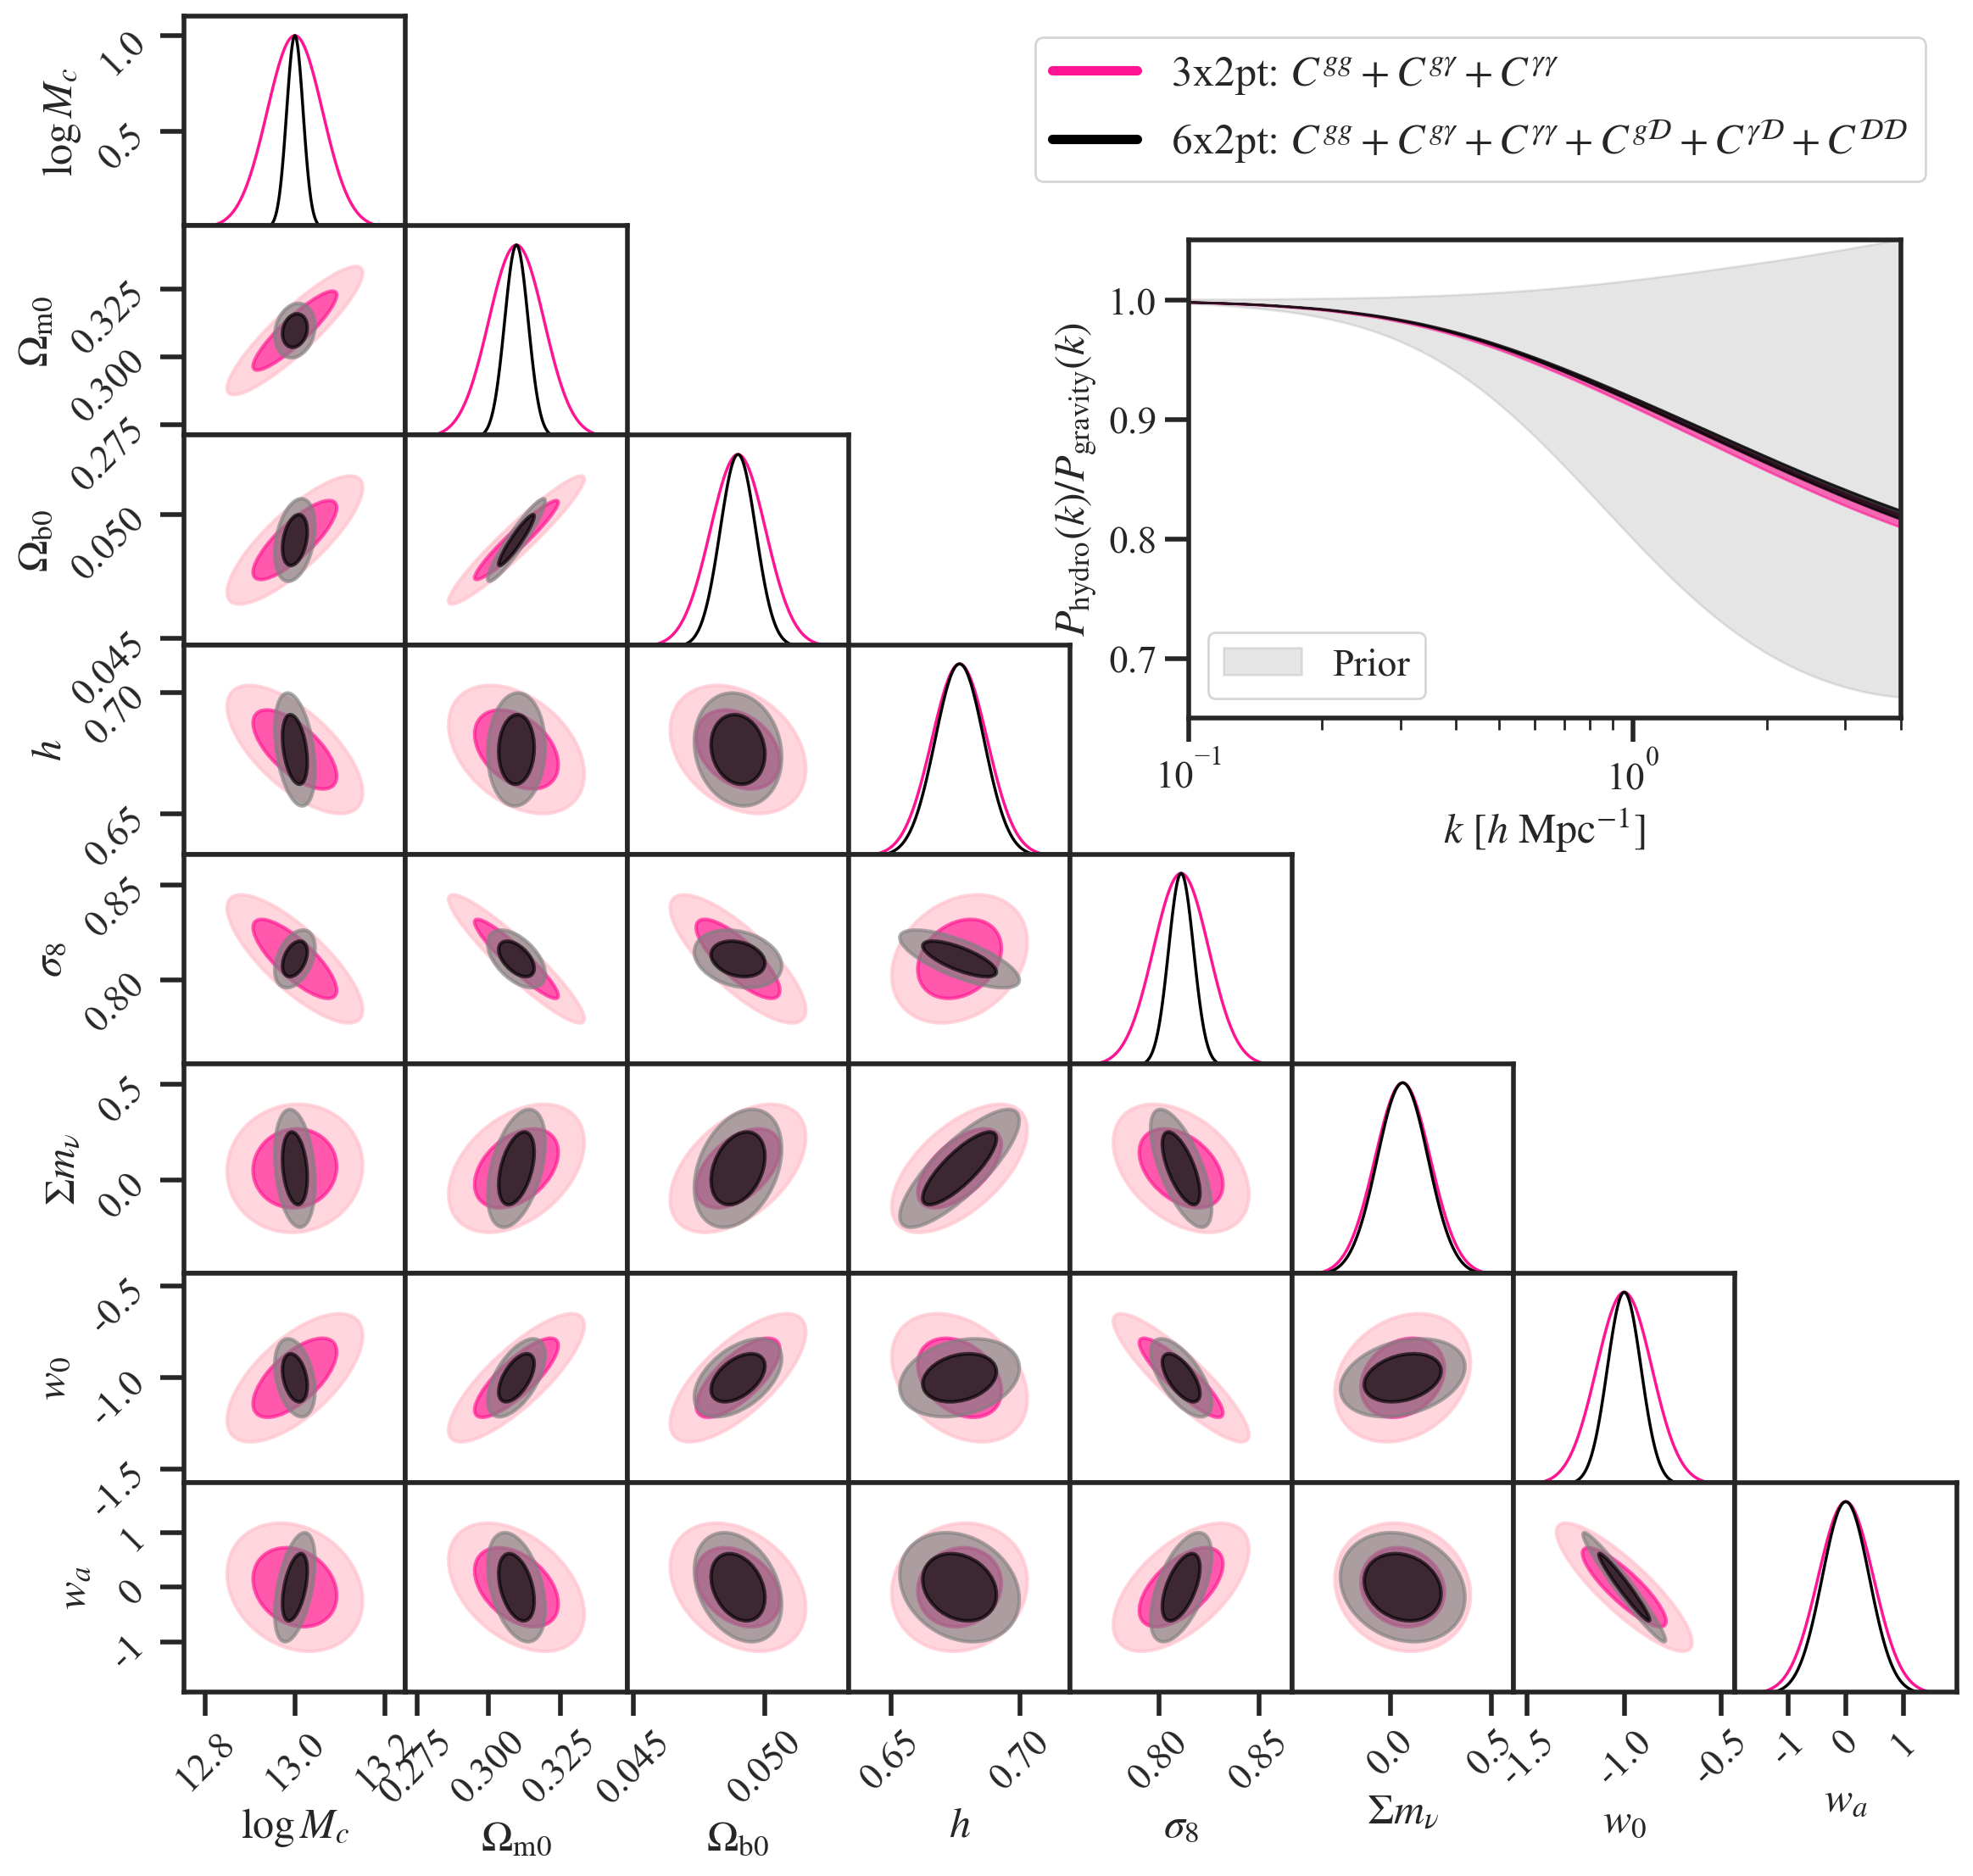

In [11]:
from matplotlib.ticker import MaxNLocator
from matplotlib.patches import Ellipse
from scipy.stats import chi2

def get_error_ellipse(cov_ij, nsig=1):
    vals, vecs = np.linalg.eigh(cov_ij)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]
    theta = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
    chi2_val = chi2.ppf({1: 0.68, 2: 0.95}[nsig], df=2)
    width, height = 2 * np.sqrt(vals*chi2_val)
    return width, height, theta

def add_ellipse(ax, cov, i, j, color, label=None, nsig=1, alpha=1, zorder=1, ls="solid"):
    cov_ij = cov[np.ix_([j, i], [j, i])]
    width, height, angle = get_error_ellipse(cov_ij, nsig)
    ellipse = Ellipse(xy=(default_values[j], default_values[i]),
                      width=width, height=height, angle=angle,
                      edgecolor=color, facecolor=color, lw=1.5, label=label,
                      alpha=alpha, zorder=zorder, ls=ls)
    ax.add_patch(ellipse)
    
colors = {
    '3x2pt': ['deeppink', 'pink'],
    '6x2pt': ['black', 'gray']
}
ls = {
    '3x2pt': 'solid',
    '6x2pt': 'dotted'
}
labels = {
    '3x2pt': r"3x2pt: $C^{gg} + C^{g\gamma} + C^{\gamma \gamma}$", 
    '6x2pt': r"6x2pt: $C^{gg} + C^{g\gamma} + C^{\gamma \gamma} + C^{g\mathcal{D}} + C^{\gamma\mathcal{D}} + C^{\mathcal{DD}}$"
}


param_labels = [r'$\log M_c$', r'$\Omega_\mathrm{m0}$', r'$\Omega_\mathrm{b0}$', r'$h$', r'$\sigma_8$', r'$\Sigma m_\nu$', r'$w_0$', r'$w_a$']
n_params = len(param_names)

# --- Create figure grid ---
fig, axes = plt.subplots(n_params, n_params, figsize=(1.5*n_params, 1.5*n_params))

n=4
for label in covs.keys():
    for i in range(n_params):
        for j in range(n_params):
            ax = axes[i, j]
            ax.tick_params(axis='x', labelrotation=45)
            ax.tick_params(axis='y', labelrotation=45)

            # Hide ticks for internal axes
            if i != n_params - 1: ax.set_xticks([])
            if j > 0: ax.set_yticks([])

            # Set axis labels on edges
            if i == n_params-1: ax.set_xlabel(param_labels[j])
            if j == 0: ax.set_ylabel(param_labels[i])

            # Diagonal plots: 1D Gaussian for each parameter
            if i == j:
                cov = covs[label]
                sigma = np.sqrt(cov[i, i])
                x = np.linspace(-3*sigma, 3*sigma, 100)
                y = np.exp(-0.5*(x/sigma)**2)
                ax.plot(x + default_values[j], y / y.max(), color=colors[label][0], lw=1.25)
                ax.plot([], [], color=colors[label][0], label=labels[label], lw=4)
                
                # Set limits
                ax.set_xlim((-n*np.sqrt(covs['3x2pt'][j,j])) + default_values[j],
                            ( n*np.sqrt(covs['3x2pt'][j,j])) + default_values[j])
                ax.set_ylim(0.01, 1.1)

            # Off-diagonal plots: ellipses
            elif i > j:
                cov = covs[label]
                add_ellipse(ax, cov, i, j, color=colors[label][1], nsig=2,
                            label=label if i == n_params-1 and j == 0 else None, alpha=0.65)
                add_ellipse(ax, cov, i, j, color=colors[label][0], nsig=1,
                            label=label if i == n_params-1 and j == 0 else None, alpha=0.65)
                
                # Set limits
                ax.set_xlim((-n*np.sqrt(covs['3x2pt'][j,j])) + default_values[j],
                            ( n*np.sqrt(covs['3x2pt'][j,j])) + default_values[j])
                ax.set_ylim((-n*np.sqrt(covs['3x2pt'][i,i])) + default_values[i],
                            ( n*np.sqrt(covs['3x2pt'][i,i])) + default_values[i])

            else:
                ax.axis('off')  # upper triangle
            


plt.tight_layout()
plt.subplots_adjust(top=0.93, wspace=0, hspace=0)
axes[0,0].legend(loc="upper center", bbox_to_anchor=(5.85, 1), fontsize=18)

def get_band(x, qlo=16, qhi=84):
    med = np.median(x, axis=0)
    lo  = np.percentile(x, qlo, axis=0)
    hi  = np.percentile(x, qhi, axis=0)
    return med, lo, hi

k = np.geomspace(1e-4, 1e2, 1000)

new_ax = fig.add_axes([0.6, 0.585, 0.35, 0.235])  # adjust numbers to taste

ratio_spk_lo, ratio_spk_med, ratio_spk_hi = np.load('data/frb_results/prior/spk_BCEmu1_prior_fullrange_feedbackonly.npy')
new_ax.fill_between(k/0.6766, ratio_spk_lo, ratio_spk_hi, color='gray', alpha=0.2, label="Prior")


ratio_spk_med_3x2pt, ratio_spk_lo_3x2pt, ratio_spk_hi_3x2pt = get_band(SPk_3x2pt)
ratio_spk_med_6x2pt, ratio_spk_lo_6x2pt, ratio_spk_hi_6x2pt = get_band(SPk_6x2pt)

new_ax.fill_between(k/0.6766, ratio_spk_lo_3x2pt, ratio_spk_hi_3x2pt, color="deeppink", alpha=0.6)
new_ax.fill_between(k/0.6766, ratio_spk_lo_6x2pt, ratio_spk_hi_6x2pt, color="black", alpha=0.8)

new_ax.set_xscale("log")
new_ax.set_ylim(0.65, 1.05)
new_ax.set_xlim(0.1, 4)
new_ax.set_xlabel(r'$k$ $[h~\mathrm{Mpc}^{-1}]$')
new_ax.set_ylabel(r'$P_\mathrm{hydro}(k)/P_\mathrm{gravity}(k)$')
new_ax.legend(loc="lower left")
plt.savefig('figures/fisher_forecast.pdf', dpi=400, bbox_inches='tight')

